# Cost-Sensitive Threshold Tuning: Costs That Vary Per Instance

In [part B](09b_threshold_tuning.ipynb) every false negative cost the same fixed amount, and every false positive cost another fixed amount. We could write the whole policy as a single 5:1 gain matrix.

Real money is rarely that tidy:

- Missing a €10 fraudulent charge is annoying; missing a €5,000 one is a disaster. The cost of a **false negative scales with the transaction amount**.
- So the value of each decision is *different for every row* — we can no longer collapse it into one constant matrix.

In this notebook we follow scikit-learn's [cost-sensitive learning tutorial](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html) on credit-card fraud and:

- Write a **business metric** that turns each accept/reject decision into euros, using the per-transaction `Amount`.
- Pass that amount to the scorer with scikit-learn's [metadata routing](https://scikit-learn.org/stable/metadata_routing.html).
- Tune the threshold with [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html), then freeze it for deployment with [`FixedThresholdClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.FixedThresholdClassifier.html).

In [1]:
# https://pandas.pydata.org/docs/
import pandas as pd

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://seaborn.pydata.org/
import seaborn as sns

# https://scikit-learn.org/stable/modules/generated/sklearn.config_context.html
from sklearn import set_config

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html
from sklearn.datasets import fetch_openml

# https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
from sklearn.dummy import DummyClassifier

# https://scikit-learn.org/stable/modules/generated/sklearn.frozen.FrozenEstimator.html
from sklearn.frozen import FrozenEstimator

# https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
from sklearn.linear_model import LogisticRegression

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html
from sklearn.metrics import make_scorer

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.FixedThresholdClassifier.html
from sklearn.model_selection import (
    train_test_split,
    TunedThresholdClassifierCV,
    FixedThresholdClassifier,
)

# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html
from sklearn.pipeline import make_pipeline

# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## Load the credit-card dataset

We use the [credit-card fraud](https://www.openml.org/d/1597) dataset from OpenML — anonymised European card transactions.

- Around **285,000 transactions**, each described by a `Time` column, an `Amount`, and 28 anonymised PCA features (`V1`…`V28`).
- The target `Class` is `1` for fraud and `0` for a legitimate charge.
- This is a heavy download and parse (~30 seconds on first run).

In [2]:
credit_card = fetch_openml(data_id=1597, as_frame=True)

# Everything except the label is a feature; Amount stays in as a predictor too.
data = credit_card.frame.drop(columns=["Class"])
target = credit_card.frame["Class"].astype(int)

print(f"Transactions: {data.shape[0]:,}")
print(f"Features:     {data.shape[1]}")

Transactions: 284,807
Features:     29


## Explore the class balance and fraud amounts

- The data is **extremely imbalanced**: fraud is well under 1% of transactions, so accuracy is meaningless here (predicting "never fraud" already scores ~99.8%).
- The fraudulent `Amount` distribution is what makes the cost *variable* — most frauds are small, but the tail of large charges is where the real losses hide.

In [3]:
# normalize=True turns the counts into proportions of the whole dataset.
class_share = target.value_counts(normalize=True)

print(f"Legitimate (0): {class_share[0]:.4%}")
print(f"Fraud      (1): {class_share[1]:.4%}")
print(f"Fraud cases:    {target.sum():,}")

Legitimate (0): 99.8273%
Fraud      (1): 0.1727%
Fraud cases:    492


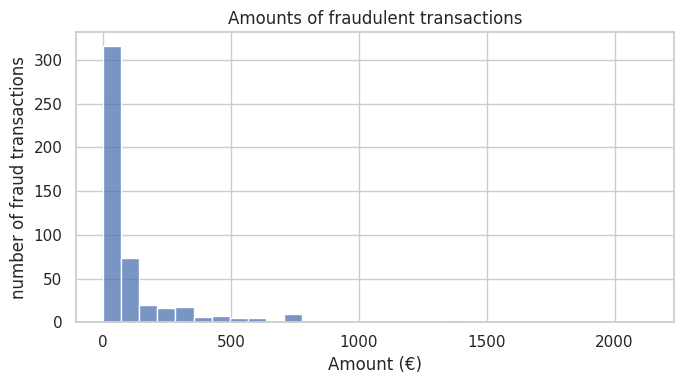

In [4]:
# Keep only the amounts of the transactions that turned out to be fraud.
amount_fraud = data.loc[target == 1, "Amount"]

fig, ax = plt.subplots(figsize=(7, 4))

sns.histplot(
    x=amount_fraud,  # euro value of each fraudulent transaction
    bins=30,  # group amounts into 30 buckets
    ax=ax,
)

ax.set_xlabel("Amount (€)")
ax.set_ylabel("number of fraud transactions")
ax.set_title("Amounts of fraudulent transactions")
plt.tight_layout()
plt.show()

## Define the business metric

Instead of an abstract cost, we put a **euro value on every one of the four outcomes**, following the tutorial:

- **Legitimate accepted** (true negative): we earn a 2% fee on the amount.
- **Fraud accepted** (false negative): we lose the *entire* amount — this is the term that varies per transaction.
- **Legitimate refused** (false positive): an annoyed customer costs us a flat €5.
- **Fraud refused** (true positive): blocking it is worth a flat €50.

The metric sums these into the **total benefit** (in €) of a set of decisions — higher is better, which already matches the scorer convention.

In [5]:
def business_metric(y_true, y_pred, amount):
    """Total euro benefit of accept/reject decisions, given each transaction amount."""
    # Boolean masks for each cell of the confusion matrix.
    mask_true_positive = (y_true == 1) & (y_pred == 1)  # fraud, correctly refused
    mask_true_negative = (y_true == 0) & (y_pred == 0)  # legit, correctly accepted
    mask_false_positive = (y_true == 0) & (y_pred == 1)  # legit, wrongly refused
    mask_false_negative = (y_true == 1) & (y_pred == 0)  # fraud, wrongly accepted

    fraudulent_refuse = mask_true_positive.sum() * 50  # +€50 per blocked fraud
    fraudulent_accept = -amount[mask_false_negative].sum()  # lose the whole amount
    legitimate_refuse = mask_false_positive.sum() * -5  # -€5 per annoyed customer
    legitimate_accept = (amount[mask_true_negative] * 0.02).sum()  # 2% fee earned

    return (
        fraudulent_refuse
        + fraudulent_accept
        + legitimate_refuse
        + legitimate_accept
    )

### Route the amount to the scorer

The `Amount` plays **two roles**: it is a feature the model trains on, *and* it is needed by the business metric to price each decision.

- To feed it to the scorer (but not as another fit argument) we use scikit-learn's **metadata routing**.
- `set_config(enable_metadata_routing=True)` switches the mechanism on.
- `.set_score_request(amount=True)` declares that this scorer expects an `amount` keyword, which `TunedThresholdClassifierCV` will then forward automatically.

In [6]:
set_config(enable_metadata_routing=True)

business_scorer = make_scorer(business_metric).set_score_request(amount=True)

## Split with the transaction amount

Because the amount is also a piece of metadata, we pull it out as its own array and split it **alongside** the features and target.

- A 50/50 split keeps enough of the ~500 fraud cases in each half.
- `stratify=target` preserves the tiny fraud rate in both train and test.

In [7]:
amount = credit_card.frame["Amount"].to_numpy()

data_train, data_test, target_train, target_test, amount_train, amount_test = (
    train_test_split(
        data,
        target,
        amount,
        stratify=target,  # keep the same fraud rate in both halves
        test_size=0.5,  # 50/50 so each half holds enough fraud cases
        random_state=42,
    )
)

## Baseline policies

Before any model, we price two trivial policies with the same business metric:

- **Always accept** every transaction (predict class `0`) — collect fees but eat all fraud losses.
- **Always reject** every transaction (predict class `1`) — block all fraud but alienate every customer.

[`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) with `strategy="constant"` gives us these fixed-decision policies. Any real model must beat the better of the two.

In [8]:
always_accept = DummyClassifier(strategy="constant", constant=0)
always_accept.fit(data_train, target_train)

always_reject = DummyClassifier(strategy="constant", constant=1)
always_reject.fit(data_train, target_train)

# The scorer applies each policy to the test set and prices the decisions.
benefit_accept = business_scorer(
    always_accept, data_test, target_test, amount=amount_test
)
benefit_reject = business_scorer(
    always_reject, data_test, target_test, amount=amount_test
)

print(f"Always accept: {benefit_accept:>15,.2f} €")
print(f"Always reject: {benefit_reject:>15,.2f} €")

Always accept:      221,445.07 €
Always reject:     -698,490.00 €


## Logistic regression at the default threshold

Now a real model: a scaler feeding a logistic regression.

- We fit the pipeline as-is, then score it at its default 0.5 threshold to see if it already beats the baselines.
- Threshold tuning comes next; the model itself stays fixed.

In [9]:
model = make_pipeline(StandardScaler(), LogisticRegression(C=100))
model.fit(data_train, target_train)

benefit_default = business_scorer(
    model, data_test, target_test, amount=amount_test
)
print(f"Benefit at default threshold (0.5): {benefit_default:,.2f} €")

Benefit at default threshold (0.5): 244,919.87 €


## Tune the decision threshold

`TunedThresholdClassifierCV` scans candidate thresholds and keeps the one that maximises our **business** scorer.

- We pass `estimator=model` so it reuses the fitted pipeline and only searches the threshold.
- `thresholds=100` evaluates 100 candidate cut-offs.
- The `amount` metadata is handed to `fit`, and the meta-estimator routes it through to the scorer automatically.

In [10]:
tuned_model = TunedThresholdClassifierCV(
    estimator=model,  # reuse the fitted pipeline
    scoring=business_scorer,  # maximise euro benefit
    thresholds=100,  # number of candidate thresholds to try
    n_jobs=-1,  # evaluate folds in parallel
)
# amount is routed to the business scorer during the threshold search.
tuned_model.fit(data_train, target_train, amount=amount_train)

benefit_tuned = business_scorer(
    tuned_model, data_test, target_test, amount=amount_test
)

print( "Default threshold: 0.500")
print(f"Tuned threshold:   {tuned_model.best_threshold_:.3f}")
print(f"Benefit at tuned threshold: {benefit_tuned:,.2f} €")

Default threshold: 0.500
Tuned threshold:   0.030
Benefit at tuned threshold: 249,433.39 €


## Deploy with a fixed threshold

Once we know the threshold we want, there is no need to re-run the search every time we deploy.

- [`FixedThresholdClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.FixedThresholdClassifier.html) simply applies a chosen cut-off to a model's probabilities.
- We wrap the trained model in [`FrozenEstimator`](https://scikit-learn.org/stable/modules/generated/sklearn.frozen.FrozenEstimator.html) so it is **never refitted** — the fit step becomes instant.
- Reusing `tuned_model.best_threshold_` should reproduce the exact same benefit.

In [11]:
model_fixed_threshold = FixedThresholdClassifier(
    estimator=FrozenEstimator(model),  # frozen: predict_proba is reused, no refit
    threshold=tuned_model.best_threshold_,  # the cut-off we just found
)
model_fixed_threshold.fit(data_train, target_train)

benefit_fixed = business_scorer(
    model_fixed_threshold, data_test, target_test, amount=amount_test
)
print(f"Benefit with fixed-threshold deployment: {benefit_fixed:,.2f} €")

# Turn metadata routing back off so later code keeps the default behaviour.
set_config(enable_metadata_routing=False)

Benefit with fixed-threshold deployment: 249,433.39 €


### Benefit at a glance

Lining the policies up shows the payoff: tuning the threshold on the business metric squeezes out extra euros over both the naive baselines and the default-threshold model.

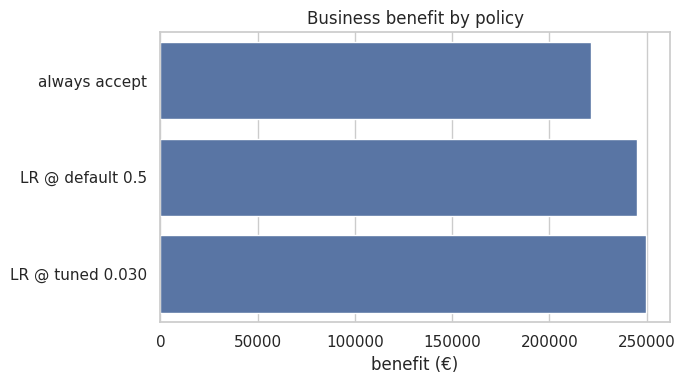

,benefit (€)
always accept,221445.0720
LR @ default 0.5,244919.8706
LR @ tuned 0.030,249433.3878


In [12]:
benefits = pd.Series(
    {
        "always accept": benefit_accept,
        # "always reject": benefit_reject,
        "LR @ default 0.5": benefit_default,
        f"LR @ tuned {tuned_model.best_threshold_:.3f}": benefit_tuned,
    },
    name="benefit (€)",
)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    x=benefits.values,  # euro benefit of each policy
    y=benefits.index,  # policy name
    ax=ax,
)

ax.set_xlabel("benefit (€)")
ax.set_ylabel("")
ax.set_title("Business benefit by policy")
plt.tight_layout()
plt.show()

benefits.to_frame()

In [13]:
# Calculate how much we saved
saved = benefit_tuned - benefit_default
print(f"We saved {saved:,.2f} € by tuning the threshold.")

We saved 4,513.52 € by tuning the threshold.


## Recap

- When the cost of an error **varies per instance** (a fraud loss equals the transaction amount), a constant gain matrix is not enough — we encode the value of each decision in a **business metric** measured in euros.
- **Metadata routing** lets us pass the per-row `Amount` to the scorer while still using it as an ordinary feature; `TunedThresholdClassifierCV` then maximises that metric directly.
- For deployment, `FixedThresholdClassifier` around a `FrozenEstimator` reproduces the tuned threshold's benefit with no costly refit or search.
- One caveat: a business metric estimated offline on historical data can be unreliable, especially with so few fraud cases. Confirm any projected gain with **A/B testing** on live traffic before trusting it.